In [40]:
import pandas as pd 

# Distribution pour la Hongrie 

In [41]:
date_419_apres_conflit = pd.to_datetime('2023-04-19')

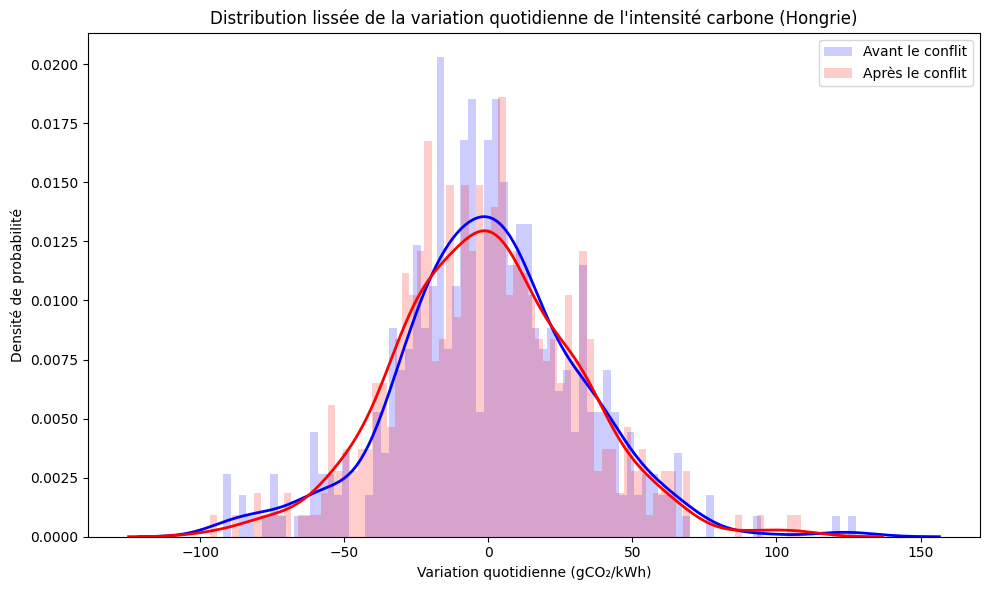

Statistique KS : 0.0511, p-value : 0.6222, différence entre courbes statistiquement significative si p<0,05
Avant conflit : écart-type = 32.12188168127344
Après conflit : écart-type = 31.39966534335933


In [42]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp

# Lire le dataset
df = pd.read_csv('hongrie_concatene.csv')

# Convertir la colonne 'Datetime (UTC)' en datetime
df['Datetime (UTC)'] = pd.to_datetime(df['Datetime (UTC)'])

# Trier les données par date
df = df.sort_values(by='Datetime (UTC)')

# Calculer la variation quotidienne de la colonne 'Carbon Intensity gCO₂eq/kWh (LCA)'
df['Variation'] = df['Carbon Intensity gCO₂eq/kWh (LCA)'].diff(7)

# Préparer les données
df_avant = df[df['Datetime (UTC)'] < pd.to_datetime('2022-02-24')]['Variation'].dropna()
df_apres = df[(df['Datetime (UTC)'] >= pd.to_datetime('2022-02-24')) & (df['Datetime (UTC)'] < date_419_apres_conflit)]['Variation'].dropna()

plt.figure(figsize=(10, 6))

# Histogrammes légers (alpha faible)
sns.histplot(df_avant, bins=80, color='blue', label='Avant le conflit',
             kde=False, stat='density', alpha=0.2, edgecolor=None)
sns.histplot(df_apres, bins=80, color='red', label='Après le conflit',
             kde=False, stat='density', alpha=0.2, edgecolor=None)

# Courbes KDE pour lisser
sns.kdeplot(df_avant, color='blue', linewidth=2)
sns.kdeplot(df_apres, color='red', linewidth=2)

# Légendes et titres
plt.title("Distribution lissée de la variation quotidienne de l'intensité carbone (Hongrie)")
plt.xlabel("Variation quotidienne (gCO₂/kWh)")
plt.ylabel("Densité de probabilité")
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()


statistic, p_value = ks_2samp(df_avant, df_apres)
print(f"Statistique KS : {statistic:.4f}, p-value : {p_value:.4f}, différence entre courbes statistiquement significative si p<0,05")

print("Avant conflit : écart-type =", df_avant.std())
print("Après conflit : écart-type =", df_apres.std())


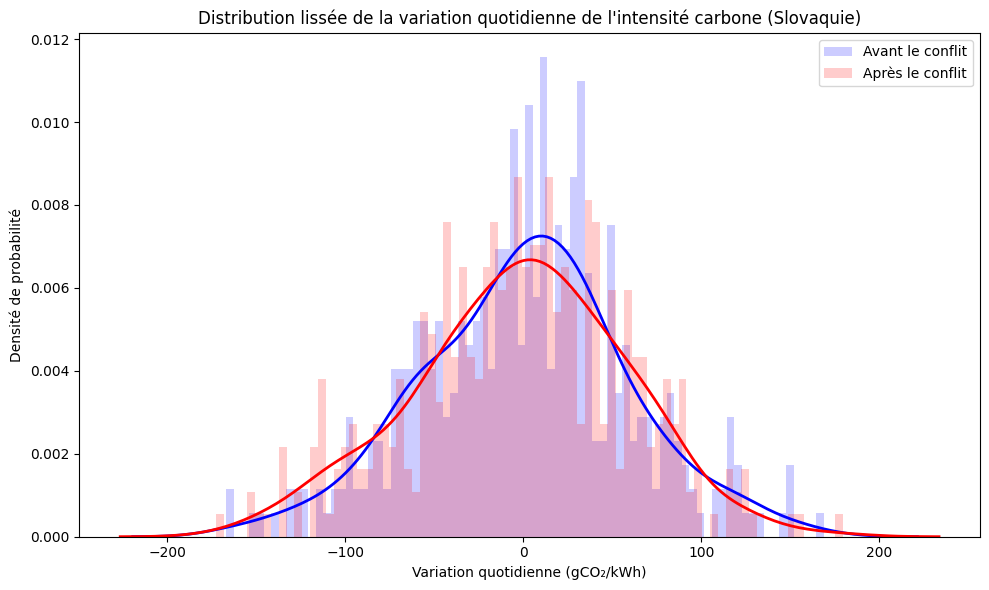

Statistique KS : 0.0418, p-value : 0.8397, différence entre courbes statistiquement significative si p<0,05
Avant conflit : écart-type = 58.42662502384054
Après conflit : écart-type = 59.997266083165655


In [43]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp

# Lire le dataset
df = pd.read_csv('slovaquie_concatene.csv')

# Convertir la colonne 'Datetime (UTC)' en datetime
df['Datetime (UTC)'] = pd.to_datetime(df['Datetime (UTC)'])

# Trier les données par date
df = df.sort_values(by='Datetime (UTC)')

# Calculer la variation quotidienne de la colonne 'Carbon Intensity gCO₂eq/kWh (LCA)'
df['Variation'] = df['Carbon Intensity gCO₂eq/kWh (LCA)'].diff(7)

# Préparer les données
df_avant = df[df['Datetime (UTC)'] < pd.to_datetime('2022-02-24')]['Variation'].dropna()
df_apres = df[(df['Datetime (UTC)'] >= pd.to_datetime('2022-02-24')) & (df['Datetime (UTC)'] < date_419_apres_conflit)]['Variation'].dropna()

plt.figure(figsize=(10, 6))

# Histogrammes légers (alpha faible)
sns.histplot(df_avant, bins=80, color='blue', label='Avant le conflit',
             kde=False, stat='density', alpha=0.2, edgecolor=None)
sns.histplot(df_apres, bins=80, color='red', label='Après le conflit',
             kde=False, stat='density', alpha=0.2, edgecolor=None)

# Courbes KDE pour lisser
sns.kdeplot(df_avant, color='blue', linewidth=2)
sns.kdeplot(df_apres, color='red', linewidth=2)

# Légendes et titres
plt.title("Distribution lissée de la variation quotidienne de l'intensité carbone (Slovaquie)")
plt.xlabel("Variation quotidienne (gCO₂/kWh)")
plt.ylabel("Densité de probabilité")
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()


statistic, p_value = ks_2samp(df_avant, df_apres)
print(f"Statistique KS : {statistic:.4f}, p-value : {p_value:.4f}, différence entre courbes statistiquement significative si p<0,05")

print("Avant conflit : écart-type =", df_avant.std())
print("Après conflit : écart-type =", df_apres.std())


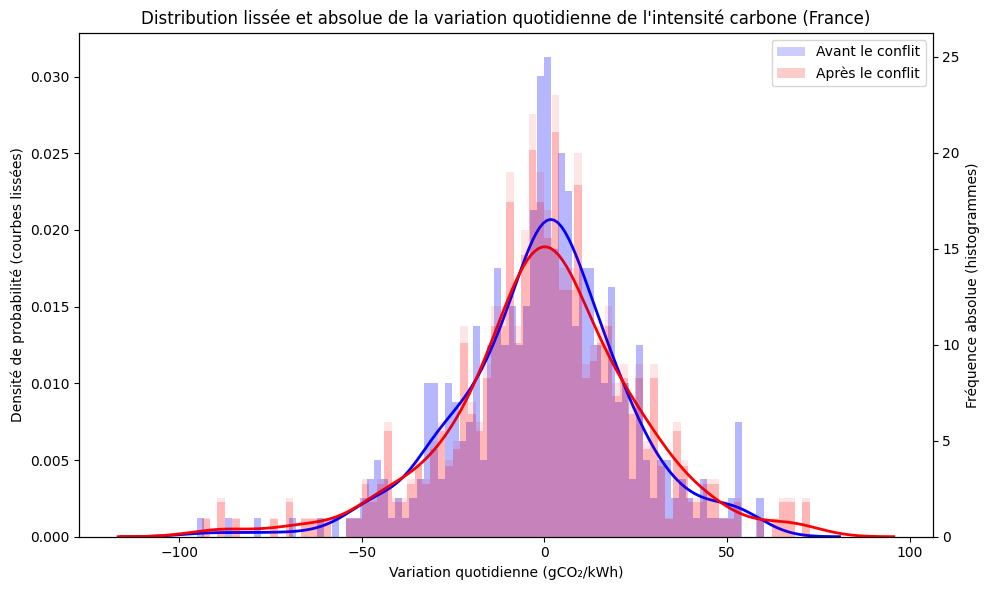

Statistique KS : 0.0432, p-value : 0.8085, différence entre courbes statistiquement significative si p<0,05
Avant conflit : écart-type = 23.13220008997003
Après conflit : écart-type = 25.63909669914336


In [44]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp

# Lire le dataset
df = pd.read_csv('france_concatene.csv')

# Convertir la colonne 'Datetime (UTC)' en datetime
df['Datetime (UTC)'] = pd.to_datetime(df['Datetime (UTC)'])

# Trier les données par date
df = df.sort_values(by='Datetime (UTC)')

# Calculer la variation quotidienne (ici hebdomadaire puisque diff(7))
df['Variation'] = df['Carbon Intensity gCO₂eq/kWh (LCA)'].diff(7)

# Définir la date de coupure après le conflit
date_419_apres_conflit = pd.to_datetime('2023-04-19')  # À adapter si tu as une autre date

# Séparer les périodes
df_avant = df[df['Datetime (UTC)'] < pd.to_datetime('2022-02-24')]['Variation'].dropna()
df_apres = df[(df['Datetime (UTC)'] >= pd.to_datetime('2022-02-24')) & 
              (df['Datetime (UTC)'] < date_419_apres_conflit)]['Variation'].dropna()

# Création du plot principal
fig, ax1 = plt.subplots(figsize=(10, 6))

# Histogrammes légers (proportion / densité)
sns.histplot(df_avant, bins=80, color='blue', label='Avant le conflit',
             kde=False, stat='density', alpha=0.2, edgecolor=None, ax=ax1)
sns.histplot(df_apres, bins=80, color='red', label='Après le conflit',
             kde=False, stat='density', alpha=0.2, edgecolor=None, ax=ax1)

# Courbes KDE
sns.kdeplot(df_avant, color='blue', linewidth=2, ax=ax1)
sns.kdeplot(df_apres, color='red', linewidth=2, ax=ax1)

# Axe secondaire pour les histogrammes absolus
ax2 = ax1.twinx()

# Histogrammes en fréquence (valeurs absolues)
sns.histplot(df_avant, bins=80, color='blue',
             kde=False, stat='count', alpha=0.1, edgecolor=None, ax=ax2)
sns.histplot(df_apres, bins=80, color='red',
             kde=False, stat='count', alpha=0.1, edgecolor=None, ax=ax2)

# Légendes et titres
ax1.set_title("Distribution lissée et absolue de la variation quotidienne de l'intensité carbone (France)")
ax1.set_xlabel("Variation quotidienne (gCO₂/kWh)")
ax1.set_ylabel("Densité de probabilité (courbes lissées)", color='black')
ax2.set_ylabel("Fréquence absolue (histogrammes)", color='black')

# Ajouter une seule légende cohérente
lines_1, labels_1 = ax1.get_legend_handles_labels()
ax1.legend(lines_1, labels_1, loc='upper right')

plt.tight_layout()
plt.show()

# Test de Kolmogorov-Smirnov
statistic, p_value = ks_2samp(df_avant, df_apres)
print(f"Statistique KS : {statistic:.4f}, p-value : {p_value:.4f}, différence entre courbes statistiquement significative si p<0,05")

print("Avant conflit : écart-type =", df_avant.std())
print("Après conflit : écart-type =", df_apres.std())


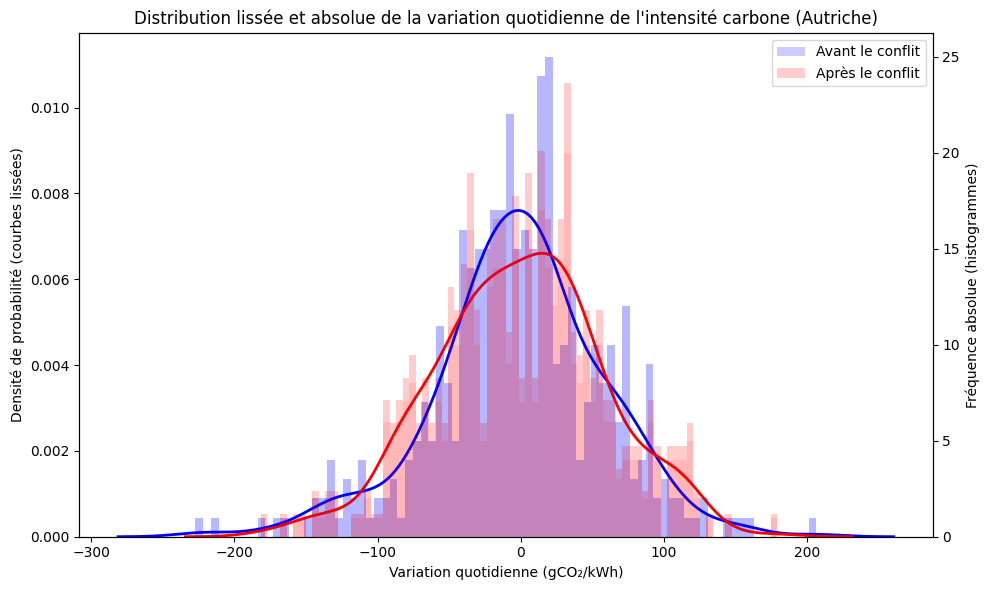

Statistique KS : 0.0571, p-value : 0.4821, différence entre courbes statistiquement significative si p<0,05
Avant conflit : écart-type = 60.09624715852041
Après conflit : écart-type = 58.81423325551889


In [45]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp

# Lire le dataset
df = pd.read_csv('AT_concatene.csv', usecols=range(9))

# Convertir la colonne 'Datetime (UTC)' en datetime
df['Datetime (UTC)'] = pd.to_datetime(df['Datetime (UTC)'])

# Trier les données par date
df = df.sort_values(by='Datetime (UTC)')

# Calculer la variation quotidienne (ici hebdomadaire puisque diff(7))
df['Variation'] = df['Carbon intensity gCO₂eq/kWh (direct)'].diff(7)

# Définir la date de coupure après le conflit
date_419_apres_conflit = pd.to_datetime('2023-04-19')  # À adapter si tu as une autre date

# Séparer les périodes
df_avant = df[df['Datetime (UTC)'] < pd.to_datetime('2022-02-24')]['Variation'].dropna()
df_apres = df[(df['Datetime (UTC)'] >= pd.to_datetime('2022-02-24')) & 
              (df['Datetime (UTC)'] < date_419_apres_conflit)]['Variation'].dropna()

# Création du plot principal
fig, ax1 = plt.subplots(figsize=(10, 6))

# Histogrammes légers (proportion / densité)
sns.histplot(df_avant, bins=80, color='blue', label='Avant le conflit',
             kde=False, stat='density', alpha=0.2, edgecolor=None, ax=ax1)
sns.histplot(df_apres, bins=80, color='red', label='Après le conflit',
             kde=False, stat='density', alpha=0.2, edgecolor=None, ax=ax1)

# Courbes KDE
sns.kdeplot(df_avant, color='blue', linewidth=2, ax=ax1)
sns.kdeplot(df_apres, color='red', linewidth=2, ax=ax1)

# Axe secondaire pour les histogrammes absolus
ax2 = ax1.twinx()

# Histogrammes en fréquence (valeurs absolues)
sns.histplot(df_avant, bins=80, color='blue',
             kde=False, stat='count', alpha=0.1, edgecolor=None, ax=ax2)
sns.histplot(df_apres, bins=80, color='red',
             kde=False, stat='count', alpha=0.1, edgecolor=None, ax=ax2)

# Légendes et titres
ax1.set_title("Distribution lissée et absolue de la variation quotidienne de l'intensité carbone (Autriche)")
ax1.set_xlabel("Variation quotidienne (gCO₂/kWh)")
ax1.set_ylabel("Densité de probabilité (courbes lissées)", color='black')
ax2.set_ylabel("Fréquence absolue (histogrammes)", color='black')

# Ajouter une seule légende cohérente
lines_1, labels_1 = ax1.get_legend_handles_labels()
ax1.legend(lines_1, labels_1, loc='upper right')

plt.tight_layout()
plt.show()

# Test de Kolmogorov-Smirnov
statistic, p_value = ks_2samp(df_avant, df_apres)
print(f"Statistique KS : {statistic:.4f}, p-value : {p_value:.4f}, différence entre courbes statistiquement significative si p<0,05")

print("Avant conflit : écart-type =", df_avant.std())
print("Après conflit : écart-type =", df_apres.std())


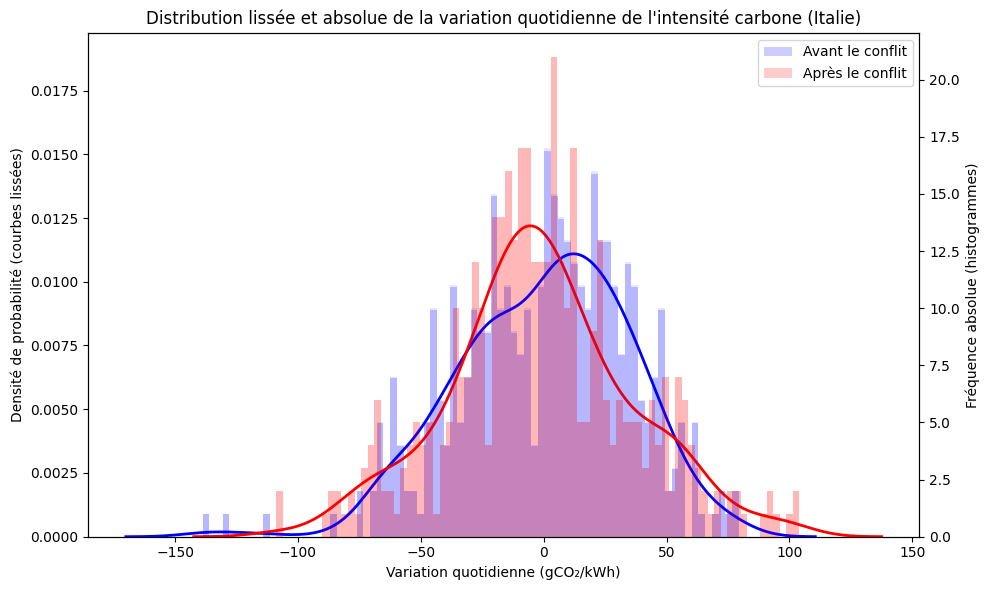

Statistique KS : 0.0950, p-value : 0.0429, différence entre courbes statistiquement significative si p<0,05
Avant conflit : écart-type = 34.694229076380694
Après conflit : écart-type = 37.32636604504326


In [46]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp

# Lire le dataset
df = pd.read_csv('IT_concatene.csv', usecols=range(9))

# Convertir la colonne 'Datetime (UTC)' en datetime
df['Datetime (UTC)'] = pd.to_datetime(df['Datetime (UTC)'])

# Trier les données par date
df = df.sort_values(by='Datetime (UTC)')

# Calculer la variation quotidienne (ici hebdomadaire puisque diff(7))
df['Variation'] = df['Carbon intensity gCO₂eq/kWh (direct)'].diff(7)

# Définir la date de coupure après le conflit
date_419_apres_conflit = pd.to_datetime('2023-04-19')  # À adapter si tu as une autre date

# Séparer les périodes
df_avant = df[df['Datetime (UTC)'] < pd.to_datetime('2022-02-24')]['Variation'].dropna()
df_apres = df[(df['Datetime (UTC)'] >= pd.to_datetime('2022-02-24')) & 
              (df['Datetime (UTC)'] < date_419_apres_conflit)]['Variation'].dropna()

# Création du plot principal
fig, ax1 = plt.subplots(figsize=(10, 6))

# Histogrammes légers (proportion / densité)
sns.histplot(df_avant, bins=80, color='blue', label='Avant le conflit',
             kde=False, stat='density', alpha=0.2, edgecolor=None, ax=ax1)
sns.histplot(df_apres, bins=80, color='red', label='Après le conflit',
             kde=False, stat='density', alpha=0.2, edgecolor=None, ax=ax1)

# Courbes KDE
sns.kdeplot(df_avant, color='blue', linewidth=2, ax=ax1)
sns.kdeplot(df_apres, color='red', linewidth=2, ax=ax1)

# Axe secondaire pour les histogrammes absolus
ax2 = ax1.twinx()

# Histogrammes en fréquence (valeurs absolues)
sns.histplot(df_avant, bins=80, color='blue',
             kde=False, stat='count', alpha=0.1, edgecolor=None, ax=ax2)
sns.histplot(df_apres, bins=80, color='red',
             kde=False, stat='count', alpha=0.1, edgecolor=None, ax=ax2)

# Légendes et titres
ax1.set_title("Distribution lissée et absolue de la variation quotidienne de l'intensité carbone (Italie)")
ax1.set_xlabel("Variation quotidienne (gCO₂/kWh)")
ax1.set_ylabel("Densité de probabilité (courbes lissées)", color='black')
ax2.set_ylabel("Fréquence absolue (histogrammes)", color='black')

# Ajouter une seule légende cohérente
lines_1, labels_1 = ax1.get_legend_handles_labels()
ax1.legend(lines_1, labels_1, loc='upper right')

plt.tight_layout()
plt.show()

# Test de Kolmogorov-Smirnov
statistic, p_value = ks_2samp(df_avant, df_apres)
print(f"Statistique KS : {statistic:.4f}, p-value : {p_value:.4f}, différence entre courbes statistiquement significative si p<0,05")

print("Avant conflit : écart-type =", df_avant.std())
print("Après conflit : écart-type =", df_apres.std())


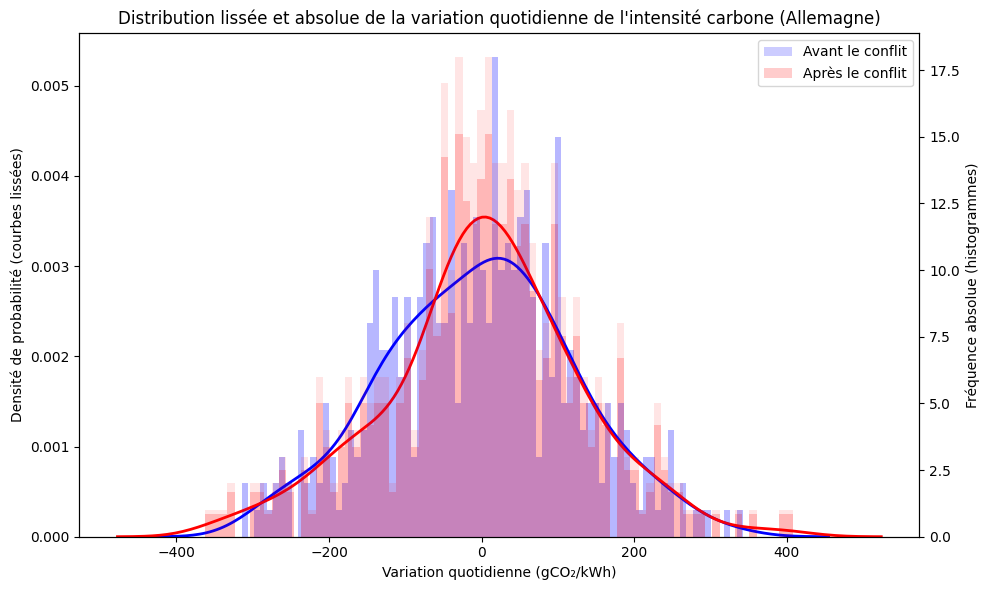

Statistique KS : 0.0751, p-value : 0.1794, différence entre courbes statistiquement significative si p<0,05
Avant conflit : écart-type = 124.99372402383891
Après conflit : écart-type = 128.5523035202019


In [47]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp

# Lire le dataset
df = pd.read_csv('DE_GERMANY_concatene.csv', usecols=range(9))

# Convertir la colonne 'Datetime (UTC)' en datetime
df['Datetime (UTC)'] = pd.to_datetime(df['Datetime (UTC)'])

# Trier les données par date
df = df.sort_values(by='Datetime (UTC)')

# Calculer la variation quotidienne (ici hebdomadaire puisque diff(7))
df['Variation'] = df['Carbon intensity gCO₂eq/kWh (direct)'].diff(7)

# Définir la date de coupure après le conflit
date_419_apres_conflit = pd.to_datetime('2023-04-19')  # À adapter si tu as une autre date

# Séparer les périodes
df_avant = df[df['Datetime (UTC)'] < pd.to_datetime('2022-02-24')]['Variation'].dropna()
df_apres = df[(df['Datetime (UTC)'] >= pd.to_datetime('2022-02-24')) & 
              (df['Datetime (UTC)'] < date_419_apres_conflit)]['Variation'].dropna()

# Création du plot principal
fig, ax1 = plt.subplots(figsize=(10, 6))

# Histogrammes légers (proportion / densité)
sns.histplot(df_avant, bins=80, color='blue', label='Avant le conflit',
             kde=False, stat='density', alpha=0.2, edgecolor=None, ax=ax1)
sns.histplot(df_apres, bins=80, color='red', label='Après le conflit',
             kde=False, stat='density', alpha=0.2, edgecolor=None, ax=ax1)

# Courbes KDE
sns.kdeplot(df_avant, color='blue', linewidth=2, ax=ax1)
sns.kdeplot(df_apres, color='red', linewidth=2, ax=ax1)

# Axe secondaire pour les histogrammes absolus
ax2 = ax1.twinx()

# Histogrammes en fréquence (valeurs absolues)
sns.histplot(df_avant, bins=80, color='blue',
             kde=False, stat='count', alpha=0.1, edgecolor=None, ax=ax2)
sns.histplot(df_apres, bins=80, color='red',
             kde=False, stat='count', alpha=0.1, edgecolor=None, ax=ax2)

# Légendes et titres
ax1.set_title("Distribution lissée et absolue de la variation quotidienne de l'intensité carbone (Allemagne)")
ax1.set_xlabel("Variation quotidienne (gCO₂/kWh)")
ax1.set_ylabel("Densité de probabilité (courbes lissées)", color='black')
ax2.set_ylabel("Fréquence absolue (histogrammes)", color='black')

# Ajouter une seule légende cohérente
lines_1, labels_1 = ax1.get_legend_handles_labels()
ax1.legend(lines_1, labels_1, loc='upper right')

plt.tight_layout()
plt.show()

# Test de Kolmogorov-Smirnov
statistic, p_value = ks_2samp(df_avant, df_apres)
print(f"Statistique KS : {statistic:.4f}, p-value : {p_value:.4f}, différence entre courbes statistiquement significative si p<0,05")

print("Avant conflit : écart-type =", df_avant.std())
print("Après conflit : écart-type =", df_apres.std())


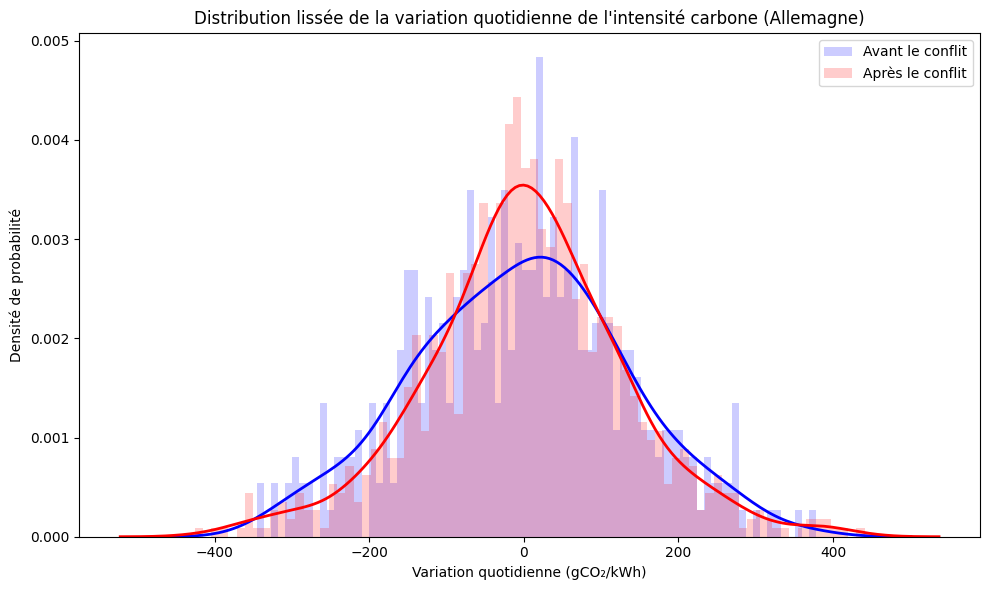

Statistique KS : 0.0731, p-value : 0.0805, différence entre courbes statistiquement significative si p<0,05
Avant conflit : écart-type = 136.9516103606649
Après conflit : écart-type = 128.98809306366982


In [48]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import ks_2samp

# Lire le dataset
df = pd.read_csv('DE_GERMANY_concatene.csv', usecols=range(9))

# Convertir la colonne 'Datetime (UTC)' en datetime
df['Datetime (UTC)'] = pd.to_datetime(df['Datetime (UTC)'])

# Trier les données par date
df = df.sort_values(by='Datetime (UTC)')

# Calculer la variation quotidienne de la colonne 'Carbon Intensity gCO₂eq/kWh (LCA)'
df['Variation'] = df['Carbon intensity gCO₂eq/kWh (Life cycle)'].diff(7)

# Préparer les données
df_avant = df[df['Datetime (UTC)'] < pd.to_datetime('2022-02-24')]['Variation'].dropna()
df_apres = df[df['Datetime (UTC)'] >= pd.to_datetime('2022-02-24')]['Variation'].dropna()

plt.figure(figsize=(10, 6))

# Histogrammes légers (alpha faible)
sns.histplot(df_avant, bins=80, color='blue', label='Avant le conflit',
             kde=False, stat='density', alpha=0.2, edgecolor=None)
sns.histplot(df_apres, bins=80, color='red', label='Après le conflit',
             kde=False, stat='density', alpha=0.2, edgecolor=None)

# Courbes KDE pour lisser
sns.kdeplot(df_avant, color='blue', linewidth=2)
sns.kdeplot(df_apres, color='red', linewidth=2)

# Légendes et titres
plt.title("Distribution lissée de la variation quotidienne de l'intensité carbone (Allemagne)")
plt.xlabel("Variation quotidienne (gCO₂/kWh)")
plt.ylabel("Densité de probabilité")
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()


statistic, p_value = ks_2samp(df_avant, df_apres)
print(f"Statistique KS : {statistic:.4f}, p-value : {p_value:.4f}, différence entre courbes statistiquement significative si p<0,05")

print("Avant conflit : écart-type =", df_avant.std())
print("Après conflit : écart-type =", df_apres.std())

In [49]:
import pandas as pd

# Lire le dataset
df = pd.read_csv('france_concatene.csv')

# Convertir la colonne 'Datetime (UTC)' en datetime
df['Datetime (UTC)'] = pd.to_datetime(df['Datetime (UTC)'])

# Trier les données par date
df = df.sort_values(by='Datetime (UTC)')

# Définir la date du conflit en Ukraine
date_conflit = pd.to_datetime('2022-02-24')

# Séparer les données avant et après le conflit
df_avant_conflit = df[df['Datetime (UTC)'] < date_conflit]
df_apres_conflit = df[df['Datetime (UTC)'] >= date_conflit]

# Calculer la moyenne pour chaque période
moyenne_avant_conflit = df_avant_conflit['Carbon Intensity gCO₂eq/kWh (LCA)'].mean()
moyenne_apres_conflit = df_apres_conflit['Carbon Intensity gCO₂eq/kWh (LCA)'].mean()

# Afficher les résultats
print(f"Moyenne avant le conflit (2022-02-24) : {moyenne_avant_conflit}")
print(f"Moyenne après le conflit (2022-02-24) : {moyenne_apres_conflit}")


Moyenne avant le conflit (2022-02-24) : 59.17188544152745
Moyenne après le conflit (2022-02-24) : 55.608723608445295


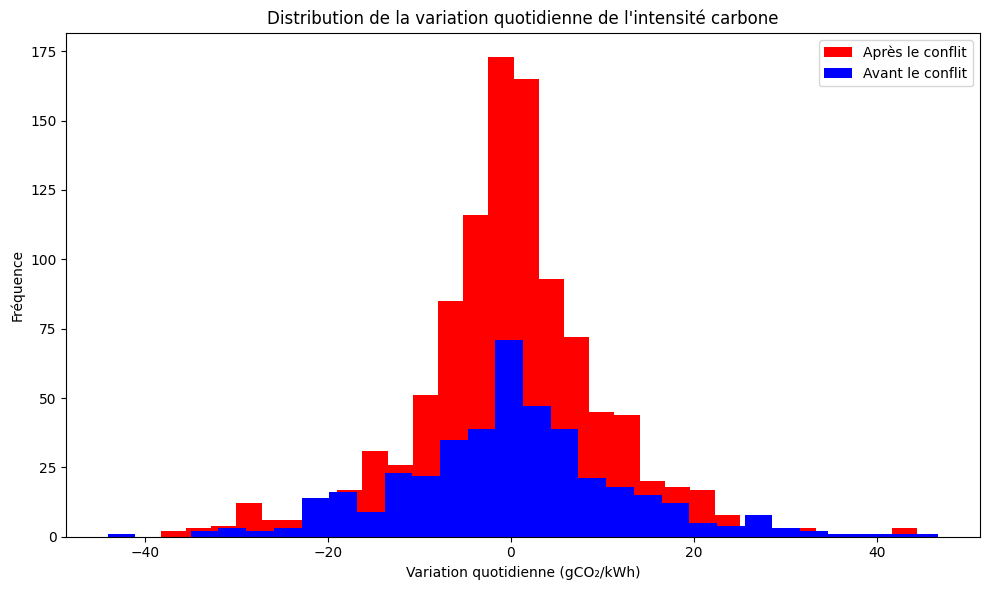

In [50]:
# Lire le dataset
dff = pd.read_csv('france_concatene.csv')

# Convertir la colonne 'Datetime (UTC)' en datetime
dff['Datetime (UTC)'] = pd.to_datetime(df['Datetime (UTC)'])

# Trier les données par date
dff = dff.sort_values(by='Datetime (UTC)')

# Calculer la variation quotidienne de la colonne 'Carbon Intensity gCO₂eq/kWh (LCA)'
dff['Variation'] = dff['Carbon Intensity gCO₂eq/kWh (LCA)'].diff()

# Définir la date du conflit en Ukraine
date_conflit = pd.to_datetime('2022-02-24')

# Séparer les données avant et après le conflit
dff_avant_conflit = dff[dff['Datetime (UTC)'] < date_conflit]
dff_apres_conflit = dff[dff['Datetime (UTC)'] >= date_conflit]

# Tracer les distributions de la variation quotidienne avant et après le conflit avec transparence
plt.figure(figsize=(10, 6))

# Tracer l'histogramme de la variation quotidienne après le conflit avec transparence
plt.hist(dff_apres_conflit['Variation'].dropna(), bins=30, color='red', alpha=1., label='Après le conflit')

# Tracer l'histogramme de la variation quotidienne avant le conflit avec transparence
plt.hist(dff_avant_conflit['Variation'].dropna(), bins=30, color='blue', alpha=1., label='Avant le conflit')



# Ajouter les labels et la légende
plt.title('Distribution de la variation quotidienne de l\'intensité carbone')
plt.xlabel('Variation quotidienne (gCO₂/kWh)')
plt.ylabel('Fréquence')
plt.legend(loc='upper right')

# Afficher le graphique
plt.tight_layout()
plt.show()

### Idées de régression sur séries temporelles

- arima, sarima, arimax pour comparer prédictions 
- 